In [1]:
import os
from operator import itemgetter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
get_ipython().magic(u'matplotlib inline')
plt.style.use('ggplot')

import tensorflow as tf

from keras import models, regularizers, layers, optimizers, losses, metrics
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

In [2]:
from keras.layers import Embedding

# The Embedding layer takes at least two arguments:
# The number of possible tokens, here 1000 (1 + maximum word index),
# and the dimensionality of the embeddings, here 64.
embedding_layer = Embedding(1000, 64)
from keras.datasets import imdb
from keras import preprocessing
from keras.utils import pad_sequences

# Number of words to consider as features
maximum_features = 10000
# After this amount of words, cut the texts
#(among top max_features most common words)
max_len = 150

# Data should be loaded as lists of integers
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=maximum_features)

x_train = x_train[:100]
y_train = y_train[:100]

# This turns our lists of integers into a 2D integer tensor of shape
#`(samples, maxlen)`
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
from keras.models import Sequential
from keras.layers import Flatten, Dense


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
model = Sequential()

# We specify the maximum input length to our Embedding layer
# so we can later flatten the embedded inputs

model.add(Embedding(10000, 8, input_length=max_len))

# We flatten the 3D tensor of embeddings
# into a 2D tensor of shape `(samples, maxlen * 8)`
model.add(Flatten())

# We add the classifier on top
model.add(Dense(1, activation='sigmoid'))

#compiling the model
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - acc: 0.5336 - loss: 0.6913 - val_acc: 0.5500 - val_loss: 0.6958
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.9078 - loss: 0.6670 - val_acc: 0.5000 - val_loss: 0.6954
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.9578 - loss: 0.6463 - val_acc: 0.5000 - val_loss: 0.6951
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 0.9656 - loss: 0.6295 - val_acc: 0.5500 - val_loss: 0.6941
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - acc: 1.0000 - loss: 0.6144 - val_acc: 0.5500 - val_loss: 0.6944
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.9898 - loss: 0.5940 - val_acc: 0.5000 - val_loss: 0.6949
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 1.0000 - loss: 0.5783 - val_acc: 0.5500 - val_loss: 0.6949
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 1.0000 - loss: 0.5607 - val_acc: 0.5000 - val_loss: 0.6951
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - acc: 1.0000 - loss: 0.5431 -

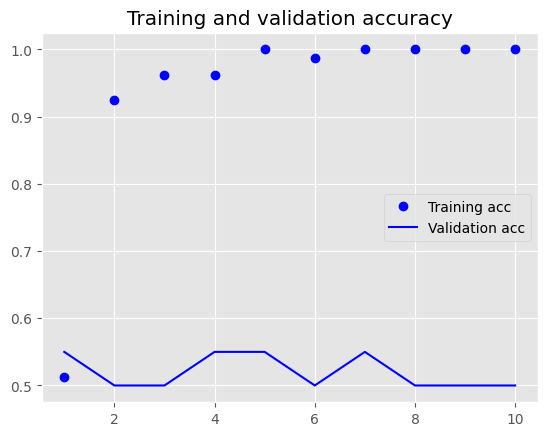

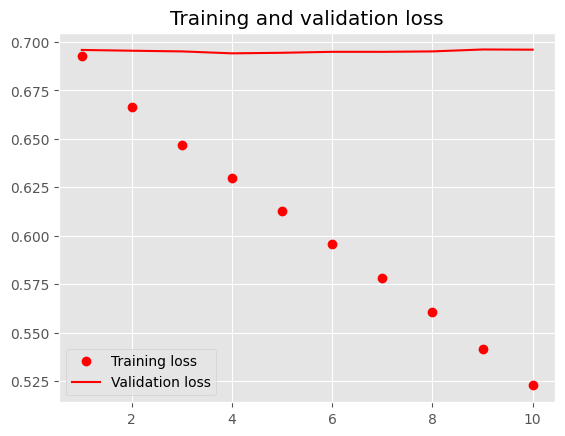

In [4]:
import matplotlib.pyplot as plt

# Training accuracy
acc = history.history["acc"]
# Validation accuracy
valid_accuracy = history.history["val_acc"]
# Training loss
loss = history.history["loss"]
# Validation loss
valid_loss = history.history["val_loss"]

#plots every epoch, here 10
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, "bo", label = "Training acc") # "bo" gives dot plot
plt.plot(epochs, valid_accuracy, "b", label = "Validation acc") # "b" gives line plot
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "ro", label = "Training loss")
plt.plot(epochs, valid_loss, "r", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()



In [5]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.5015 - loss: 0.6944
Test loss: 0.6945351362228394
Test accuracy: 0.5015599727630615


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.4189 - loss: 0.6959 - val_acc: 0.6400 - val_loss: 0.6896
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8333 - loss: 0.6769 - val_acc: 0.6300 - val_loss: 0.6892
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9255 - loss: 0.6603 - val_acc: 0.6100 - val_loss: 0.6888
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.9484 - loss: 0.6420 - val_acc: 0.6100 - val_loss: 0.6882
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9690 - loss: 0.6223 - val_acc: 0.6000 - val_loss: 0.6873
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9625 - loss: 0.5988 - val_acc: 0.6000 - val_loss: 0.6862
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9803 - loss: 0.5689 - val_acc: 0.6100 - val_loss: 0.6853
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9760 - loss: 0.5423 - val_acc: 0.6100 - val_loss: 0.6841
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9750

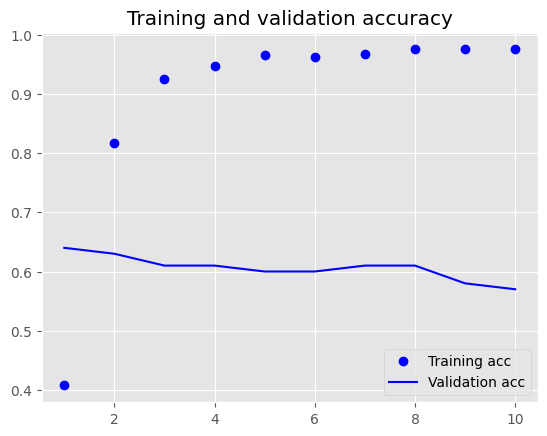

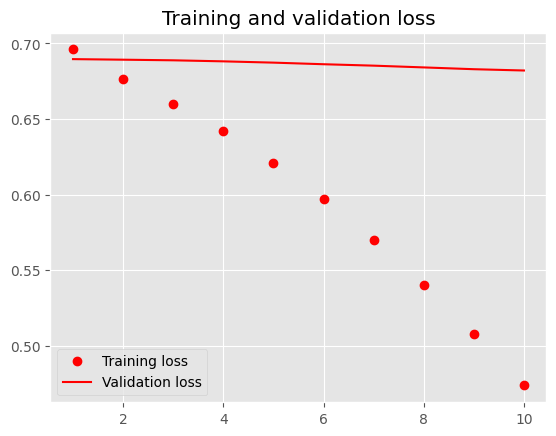

In [6]:
from keras.layers import Embedding

# The Embedding layer takes at least two arguments:
# the number of possible tokens, here 1000 (1 + maximum word index),
# and the dimensionality of the embeddings, here 64.
embedding_layer = Embedding(1000, 64)
from keras.datasets import imdb
from keras import preprocessing

# Number of words to consider as features
maximum_features = 10000
# After this amount of words, cut the texts
# (among top max_features most common words)
max_len = 150

# Data should be loaded as lists of integers
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=maximum_features)

x_train = x_train[:500]
y_train = y_train[:500]

# This turns our lists of integers
# into a 2D integer tensor of shape `(samples, maxlen)`
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
from keras.models import Sequential
from keras.layers import Flatten, Dense

model = Sequential()
# We provide our Embedding layer a maximum input length specification
# in order to flatten the embedded inputs later
model.add(Embedding(10000, 8, input_length=max_len))
# After the Embedding layer,
# our activations have shape `(samples, maxlen, 8)`.
# We flatten the 3D tensor of embeddings
# into a 2D tensor of shape `(samples, maxlen * 8)`
model.add(Flatten())

# We add the classifier on top
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)
acc = history.history["acc"] # Training accuracy
valid_accuracy = history.history["val_acc"] # Validation accuracy
loss = history.history["loss"] # Training loss
valid_loss = history.history["val_loss"] # Validation loss

epochs = range(1, len(acc) + 1) #plots every epoch, here 10

plt.plot(epochs, acc, "bo", label = "Training acc") # "bo" gives dot plot
plt.plot(epochs, valid_accuracy, "b", label = "Validation acc") # "b" gives line plot
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "ro", label = "Training loss")
plt.plot(epochs, valid_loss, "r", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [7]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.5179 - loss: 0.6924
Test loss: 0.6927376389503479
Test accuracy: 0.5194799900054932


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.5178 - loss: 0.6932 - val_acc: 0.5300 - val_loss: 0.6902
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.7516 - loss: 0.6780 - val_acc: 0.5550 - val_loss: 0.6889
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.8526 - loss: 0.6616 - val_acc: 0.5550 - val_loss: 0.6871
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9111 - loss: 0.6409 - val_acc: 0.5550 - val_loss: 0.6848
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9414 - loss: 0.6108 - val_acc: 0.5650 - val_loss: 0.6819
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9573 - loss: 0.5822 - val_acc: 0.5800 - val_loss: 0.6781
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9684 - loss: 0.5421 - val_acc: 0.5850 - val_loss: 0.6736
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9669 - loss: 0.5032 - val_acc: 0.6050 - val_loss: 0.6685
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9666 - loss:

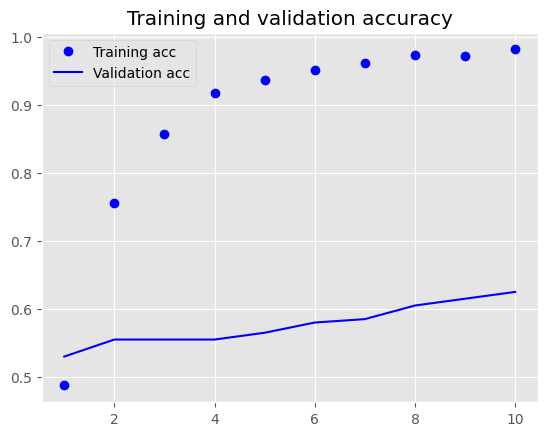

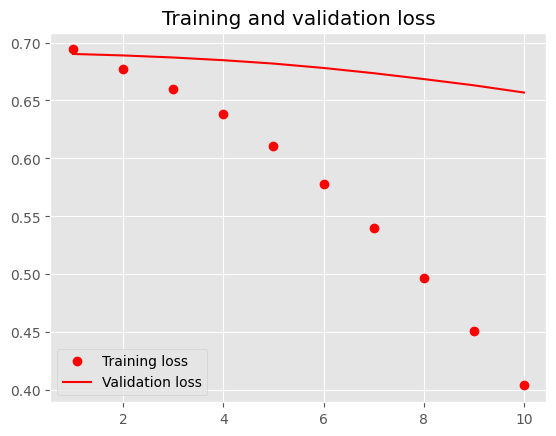

In [8]:
from keras.layers import Embedding

# The Embedding layer takes at least two arguments:
# the number of possible tokens, here 1000 (1 + maximum word index),
# and the dimensionality of the embeddings, here 64.
embedding_layer = Embedding(1000, 64)
from keras.datasets import imdb
from keras import preprocessing

# Number of words to consider as features
maximum_features = 10000
# After this amount of words, cut the texts
# (among top max_features most common words)
max_len = 150

# Data should be loaded as lists of integers
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=maximum_features)

x_train = x_train[:1000]
y_train = y_train[:1000]

# This turns our lists of integers
# into a 2D integer tensor of shape `(samples, maxlen)`
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
from keras.models import Sequential
from keras.layers import Flatten, Dense
model = Sequential()
# We provide our Embedding layer a maximum input length specification
# in order to flatten the embedded inputs later
model.add(Embedding(10000, 8, input_length=max_len))
# After the Embedding layer,
# our activations have shape `(samples, maxlen, 8)`.

# We flatten the 3D tensor of embeddings
# into a 2D tensor of shape `(samples, maxlen * 8)`
model.add(Flatten())

# We add the classifier on top
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)
acc = history.history["acc"] # Training accuracy
valid_accuracy = history.history["val_acc"] # Validation accuracy
loss = history.history["loss"] # Training loss
valid_loss = history.history["val_loss"] # Validation loss

epochs = range(1, len(acc) + 1) #plots every epoch, here 10

plt.plot(epochs, acc, "bo", label = "Training acc") # "bo" gives dot plot
plt.plot(epochs, valid_accuracy, "b", label = "Validation acc") # "b" gives line plot
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "ro", label = "Training loss")
plt.plot(epochs, valid_loss, "r", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()

In [9]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.5864 - loss: 0.6718
Test loss: 0.6722700595855713
Test accuracy: 0.5830399990081787


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc: 0.5247 - loss: 0.6918 - val_acc: 0.6380 - val_loss: 0.6775
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - acc: 0.7735 - loss: 0.6338 - val_acc: 0.7700 - val_loss: 0.5332
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8435 - loss: 0.4533 - val_acc: 0.8290 - val_loss: 0.4027
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8835 - loss: 0.3328 - val_acc: 0.8490 - val_loss: 0.3495
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9121 - loss: 0.2610 - val_acc: 0.8565 - val_loss: 0.3267
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9272 - loss: 0.2116 - val_acc: 0.8545 - val_loss: 0.3197
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9435 - loss: 0.1807 - val_acc: 0.8570 - val_loss: 0.3239
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9609 - loss: 0.1421 - val_acc: 0.8605 - val_loss: 0.3205
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - a

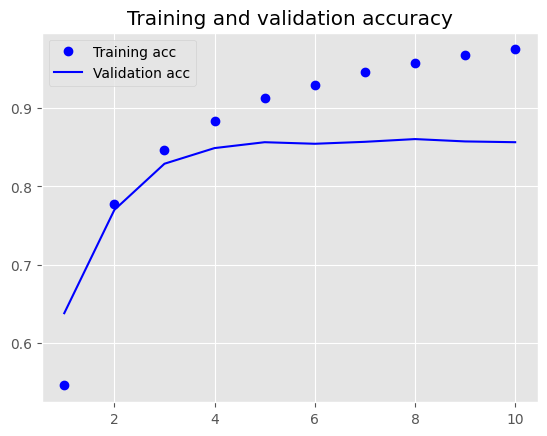

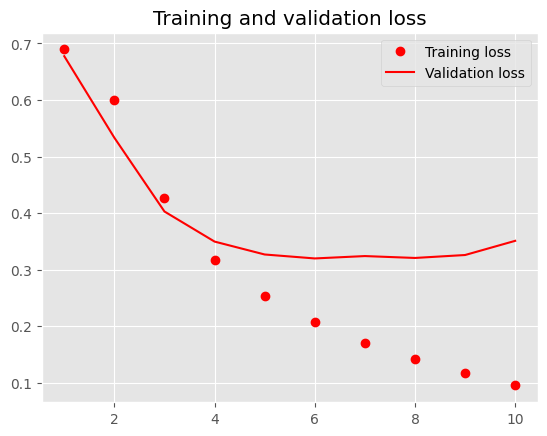

In [10]:
from keras.layers import Embedding

# The Embedding layer takes at least two arguments:
# the number of possible tokens, here 1000 (1 + maximum word index),
# and the dimensionality of the embeddings, here 64.
embedding_layer = Embedding(1000, 64)
from keras.datasets import imdb
from keras import preprocessing

# Number of words to consider as features
maximum_features = 10000
# After this amount of words, cut the texts
# (among top max_features most common words)
max_len = 150

# Data should be loaded as lists of integers
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=maximum_features)

x_train = x_train[:10000]
y_train = y_train[:10000]

# This turns our lists of integers
# into a 2D integer tensor of shape `(samples, maxlen)`
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
from keras.models import Sequential
from keras.layers import Flatten, Dense
model = Sequential()
# We provide our Embedding layer a maximum input length specification
# in order to flatten the embedded inputs later
model.add(Embedding(10000, 8, input_length=max_len))
# After the Embedding layer,
# our activations have shape `(samples, maxlen, 8)`.

# We flatten the 3D tensor of embeddings
# into a 2D tensor of shape `(samples, maxlen * 8)`
model.add(Flatten())

# We add the classifier on top
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)
acc = history.history["acc"] # Training accuracy
valid_accuracy = history.history["val_acc"] # Validation accuracy
loss = history.history["loss"] # Training loss
valid_loss = history.history["val_loss"] # Validation loss

epochs = range(1, len(acc) + 1) #plots every epoch, here 10

plt.plot(epochs, acc, "bo", label = "Training acc") # "bo" gives dot plot
plt.plot(epochs, valid_accuracy, "b", label = "Validation acc") # "b" gives line plot
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "ro", label = "Training loss")
plt.plot(epochs, valid_loss, "r", label = "Validation loss")
plt.title("Training and validation loss")
plt.legend()

plt.show()



In [11]:
test_loss, T_accuracy_acc = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8446 - loss: 0.3671
Test loss: 0.36185577511787415
Test accuracy: 0.5830399990081787


In [12]:
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  29.2M      0  0:00:02  0:00:02 --:--:-- 29.2M


In [13]:
import os
import shutil

imdb_dir = 'aclImdb'
train_dir = os.path.join(imdb_dir, 'train')

labels = []
texts = []

for label_type in ['neg', 'pos']:
    dir_name = os.path.join(train_dir, label_type)
    for fname in os.listdir(dir_name):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname), encoding='utf-8')
            texts.append(f.read())
            f.close()
            if label_type == 'neg':
                labels.append(0)
            else:
                labels.append(1)

If there is not enough training data to learn word embeddings for your particular situation, you can use pretrained word embeddings.

The training review labels (positive or negative) are compiled into a list, while the training reviews themselves are organized as a list of strings, with each string representing a single review.

**Data tokenization**

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
import numpy as np

maxlen = 150 # cuts off review after 150 words
training_samples = 100 # Trains on 100 samples
validation_samples = 10000 # Validates 10000 samples
max_words = 10000 # Considers only the top 10000 words in the dataset

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index    # Length: 88582
print("Found %s unique tokens." % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen)

labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

indices = np.arange(data.shape[0]) # Splits data into training and validation set, but shuffles is, since samples are ordered:
# all negatives first, then all positive
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:training_samples] # (200, 100)
y_train = labels[:training_samples] # shape (200,)
x_val = data[training_samples:training_samples+validation_samples] # shape (10000, 100)
y_val = labels[training_samples:training_samples+validation_samples] # shape (10000,)

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


**Downloading and preparing the word embedding for Glove**

In [15]:
import numpy as np
import requests
from io import BytesIO
import zipfile  # importing zipfile module

glove_url = 'https://nlp.stanford.edu/data/glove.6B.zip'  # URL to download GloVe embeddings
glove_zip = requests.get(glove_url)

# Unzip the contents
with zipfile.ZipFile(BytesIO(glove_zip.content)) as z:
    z.extractall('/content/glove')

# Loading GloVe embeddings into memory
embeddings_index = {}
with open('/content/glove/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


An embedding matrix is then required to be incorporated into an embedding layer. This matrix should have dimensions of (maximum words, embedding dimension), specifically 10,000 × 100. In comparison, GloVe embeddings have dimensions of 100 × 400,000.

Configuring the word embedding matrix using GloVe.

In [16]:
embedding_dimension = 100

embedding_matrix = np.zeros((max_words, embedding_dimension))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [17]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
model.add(Embedding(max_words, embedding_dimension, input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
# Add the Embedding layer with initial weights and set trainable to False
model.add(Embedding(max_words, embedding_dimension, input_length=maxlen, weights=[embedding_matrix], trainable=False))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)              │ ?                           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [19]:
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False


By incorporating pretrained word embeddings into the Embedding layer, we can set the trainable parameter to False to ensure that the Embedding layer remains untrainable when used. If trainable is set to True, the optimization process can modify the word embedding parameters. To preserve the knowledge within pretrained embeddings, it is advisable to delay updating them until the training process is complete.

In [20]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('pre_trained_glove_model.weights.h5')

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 977ms/step - acc: 0.5115 - loss: 2.3451 - val_acc: 0.5035 - val_loss: 2.1213
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 585ms/step - acc: 0.6230 - loss: 1.0018 - val_acc: 0.4965 - val_loss: 1.5936
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - acc: 0.7278 - loss: 0.6729 - val_acc: 0.5349 - val_loss: 0.7916
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 878ms/step - acc: 0.9508 - loss: 0.1840 - val_acc: 0.5302 - val_loss: 0.8424
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 442ms/step - acc: 0.9939 - loss: 0.1354 - val_acc: 0.5279 - val_loss: 0.9578
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 894ms/step - acc: 0.9908 - loss: 0.0676 - val_acc: 0.5159 - val_loss: 1.2548
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 901ms/step - acc: 1.0000 - loss: 0.0771 - val_acc: 0.5359 - val_loss: 0.8884
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 488ms/step - acc: 1.0000 - loss: 0.0298 - val_acc: 0.5140 - val_loss: 1.8959
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 878ms/step - acc: 0.9899 - loss: 

As anticipated due to the small amount of training data, the model quickly overfits. The significant fluctuations in validation accuracy are also a result of this limitation.

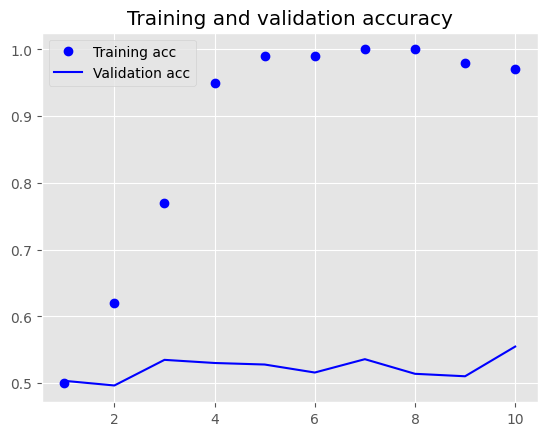

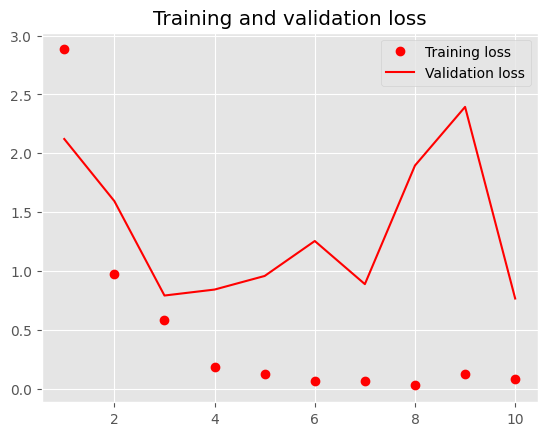

In [21]:
import matplotlib.pyplot as plt

acc = history.history['acc']
valid_accuracy = history.history['val_acc']
loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, valid_accuracy, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, valid_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [22]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.4964 - loss: 0.8401
Test loss: 0.8303006887435913
Test accuracy: 0.502839982509613


In [23]:
!pip install tensorflow
# Install tensorflow-text if not already installed
!pip install tensorflow-text

from tensorflow.keras.preprocessing.text import Tokenizer # Import Tokenizer from tensorflow.keras
from tensorflow.keras.utils import pad_sequences # Import pad_sequences from tensorflow.keras
import numpy as np

max_len = 150 # cuts off review after 150 words
training_samples = 500 # Trains on 500 samples
validation_samples = 10000 # Validates 10000 samples
max_words = 10000 # Considers only the top 10000 words in the dataset

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index    # Length: 88582
print("Found %s unique tokens." % len(word_index))

data = pad_sequences(sequences, maxlen=max_len)

labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


In [24]:
indices = np.arange(data.shape[0]) # splits data into training and validation sets,
# however since the samples are arranged, it shuffles the data: all negatives first, then all positive
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]
x_train = data[:training_samples] # (200, 100)
y_train = labels[:training_samples] # shape (200,)
x_val = data[training_samples:training_samples+validation_samples] # shape (10000, 100)
y_val = labels[training_samples:training_samples+validation_samples] # shape (10000,)
embedding_dim = 100

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [25]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
# The embeddings_initializer argument is used to initialize the embedding layer with the pretrained weights.
model.add(Embedding(max_words, embedding_dim, embeddings_initializer='uniform', input_length=maxlen))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# This line is no longer needed if you use embeddings_initializer when declaring the layer.
#model.layers[0].set_weights([embedding_matrix])
# The trainable attribute of the embedding layer is set to False to prevent the weights from being updated during training.
model.layers[0].trainable = False
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('pre_trained_glove_model.weights.h5') # Changed the filename to include .weights.h5

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 279ms/step - acc: 0.4815 - loss: 0.6931 - val_acc: 0.4975 - val_loss: 0.6972
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - acc: 0.9205 - loss: 0.5658 - val_acc: 0.4993 - val_loss: 0.7066
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - acc: 0.9534 - loss: 0.4293 - val_acc: 0.4969 - val_loss: 0.7397
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - acc: 0.9619 - loss: 0.3043 - val_acc: 0.5005 - val_loss: 0.7280
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - acc: 0.9906 - loss: 0.2108 - val_acc: 0.4971 - val_loss: 0.7621
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - acc: 0.9932 - loss: 0.1472 - val_acc: 0.5027 - val_loss: 0.7858
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - acc: 0.9918 - loss: 0.1044 - val_acc: 0.4975 - val_loss: 0.7863
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - acc: 0.9904 - loss: 0.0936 - val_acc: 0.5007 - val_loss: 0.7957
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - ac

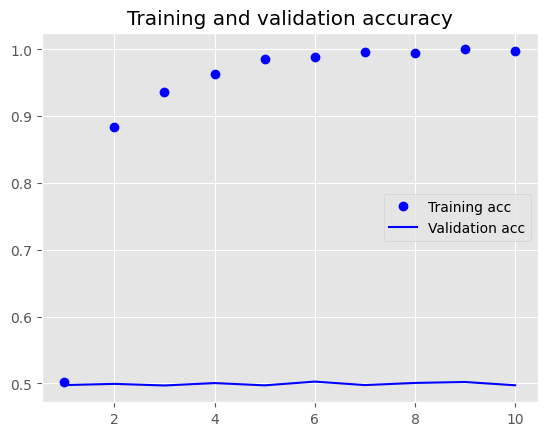

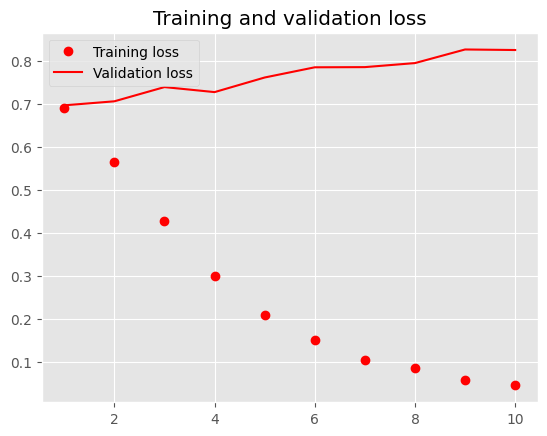

In [26]:


import matplotlib.pyplot as plt

acc = history.history['acc']
valid_accuracy = history.history['val_acc']
loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, valid_accuracy, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, valid_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [27]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.4990 - loss: 0.8145
Test loss: 0.8118312358856201
Test accuracy: 0.5008800029754639


In [28]:
!pip install keras
!pip install tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
import numpy as np


maxlen = 150 # cuts off review after 150 words
training_samples = 1000 #Trains on 1000 samples
validation_samples = 10000 # Validates o 10000 samples
max_words = 10000 # Considers only the top 10000 words in the dataset

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index      # Length: 88582
print("Found %s unique tokens." % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen)

labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


In [29]:
indices = np.arange(data.shape[0]) # splits data into training and validation sets,
# however since the samples are arranged, it shuffles the data: all negatives first, then all positive
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:training_samples] # (200, 100)
y_train = labels[:training_samples] # shape (200,)
x_val = data[training_samples:training_samples+validation_samples] # shape (10000, 100)
y_val = labels[training_samples:training_samples+validation_samples] # shape (10000,)
embedding_dim = 100

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
  embedding_vector = embeddings_index.get(word)
  if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [30]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
# Add weights parameter and set trainable to False
model.add(Embedding(max_words, embedding_dim, input_length=maxlen, weights=[embedding_matrix], trainable=False))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# Remove the line that attempts to set weights manually
# model.layers[0].set_weights([embedding_matrix]) # This line is causing the error. Remove it.
# model.layers[0].trainable = False # This is already set in the Embedding layer initialization

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('pre_trained_glove_model.weights.h5') # Changed the filename to include .weights.h5



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)             │ ?                           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_7 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - acc: 0.5108 - loss: 1.7782 - val_acc: 0.4996 - val_loss: 0.6931
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.5398 - loss: 0.7397 - val_acc: 0.5039 - val_loss: 0.7137
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - acc: 0.6481 - loss: 0.7318 - val_acc: 0.5019 - val_loss: 0.7934
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.7541 - loss: 0.5457 - val_acc: 0.4993 - val_loss: 0.7263
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - acc: 0.8764 - loss: 0.3759 - val_acc: 0.5055 - val_loss: 1.1352
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - acc: 0.8622 - loss: 0.3099 - val_acc: 0.4990 - val_loss: 0.9029
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - acc: 0.9377 - loss: 0.2225 - val_acc: 0.4919 - val_loss: 0.9119
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - acc: 0.9804 - loss: 0.1311 - val_acc: 0.5034 - val_loss: 1.1516
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - acc: 0.96

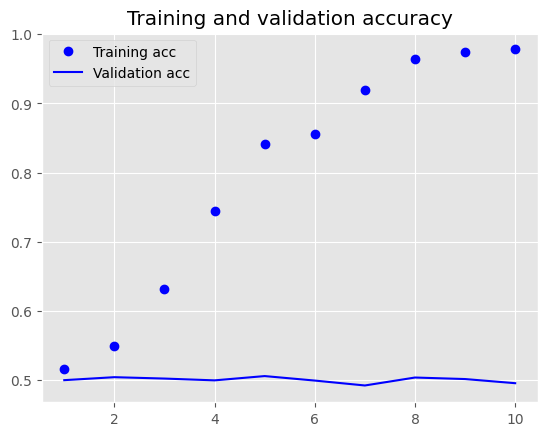

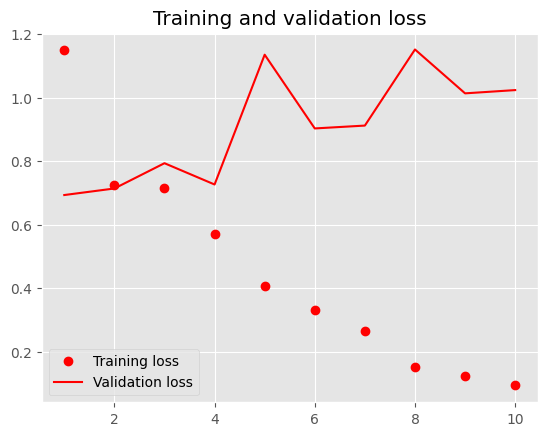

In [31]:
import matplotlib.pyplot as plt

acc = history.history['acc']
valid_accuracy = history.history['val_acc']
loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, valid_accuracy, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, valid_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [32]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.5120 - loss: 0.9649
Test loss: 0.9739123582839966
Test accuracy: 0.5085600018501282


In [33]:
!pip install tensorflow
!pip install keras

from tensorflow.keras.preprocessing.text import Tokenizer #Updated to get Tokenizer from tensorflow.keras
from keras.utils import pad_sequences
import numpy as np

max_len = 150 # cuts off review after 150 words
training_samples = 10000 # Trains on 10000 samples
validation_samples = 10000 # Validates o 10000 samples
max_words = 10000 # Considers only the top 10000 words in the dataset

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index       # Length: 88582
print("Found %s unique tokens." % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen)

labels = np.asarray(labels)
print("Shape of data tensor:", data.shape)
print("Shape of label tensor:", labels.shape)

Found 88582 unique tokens.
Shape of data tensor: (25000, 150)
Shape of label tensor: (25000,)


In [34]:
indices = np.arange(data.shape[0]) # splits data into training and validation sets,
# however since the samples are arranged, it shuffles the data: all negatives first, then all positive
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]
x_train = data[:training_samples] # (200, 100)
y_train = labels[:training_samples] # shape (200,)
x_val = data[training_samples:training_samples+validation_samples] # shape (10000, 100)
y_val = labels[training_samples:training_samples+validation_samples] # shape (10000,)
embedding_dim = 100

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

In [35]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense

model = Sequential()
# Add weights parameter and set trainable to False during initialization
model.add(Embedding(max_words, embedding_dim, input_length=maxlen, weights=[embedding_matrix], trainable=False))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# Remove the line that attempts to set weights manually
# model.layers[0].set_weights([embedding_matrix]) # This line is causing the error. Remove it.
# model.layers[0].trainable = False # This is already set in the Embedding layer initialization

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val, y_val))
model.save_weights('pre_trained_glove_model.weights.h5') # Changed the filename to include .weights.h5

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)             │ ?                           │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - acc: 0.4954 - loss: 0.8028 - val_acc: 0.4979 - val_loss: 0.6932
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - acc: 0.5010 - loss: 0.6953 - val_acc: 0.5018 - val_loss: 0.6931
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - acc: 0.5235 - loss: 0.6899 - val_acc: 0.4984 - val_loss: 0.6996
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - acc: 0.5887 - loss: 0.6680 - val_acc: 0.4982 - val_loss: 0.7032
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - acc: 0.6634 - loss: 0.6017 - val_acc: 0.5009 - val_loss: 0.7740
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - acc: 0.7200 - loss: 0.5290 - val_acc: 0.5042 - val_loss: 0.7860
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - acc: 0.7857 - loss: 0.4455 - val_acc: 0.5078 - val_loss: 0.9041
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - acc: 0.8230 - loss: 0.3761 - val_acc: 0.5070 - val_loss: 0.9876
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 

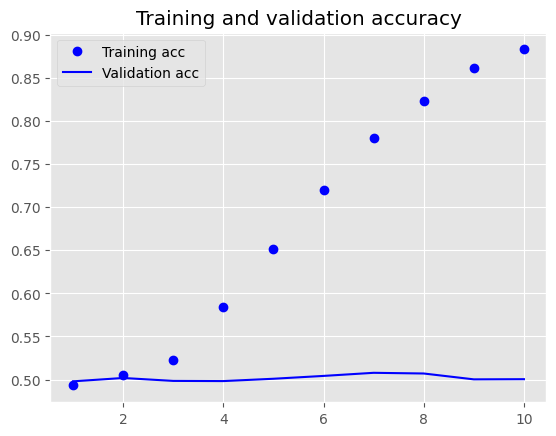

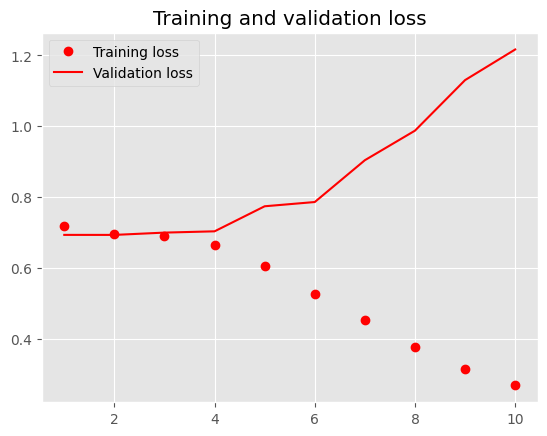

In [36]:
import matplotlib.pyplot as plt
acc = history.history['acc']
valid_accuracy = history.history['val_acc']
loss = history.history['loss']
valid_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, valid_accuracy, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, valid_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [37]:
test_loss, T_accuracy = model.evaluate(x_test, y_test)
print('Test loss:', test_loss)
print('Test accuracy:', T_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - acc: 0.5042 - loss: 1.2386
Test loss: 1.2356141805648804
Test accuracy: 0.5030800104141235
